In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
from models.mae import MAE, MAEConfig

In [4]:
import os
from functools import partial
from dataclasses import dataclass
from typing import List
from tqdm import tqdm
import tyro

import numpy as np
import jax
import jax.numpy as jnp
from jax.random import split
import optax
from flax.training.train_state import TrainState

from substrates.gol import GameOfLife
from rollout import rollout_simulation

from models.mae import MAE, MAEConfig
import util

@dataclass
class OptimizerArgs:
    batch_size: int = 32
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5
    clip_grad_norm: float = 1.0

@dataclass
class DataArgs:
    gol_params: int = 6152
    grid_size: int = 64
    t_start: int = 32
    t_end: int = 64
    dt: int | List[int] = 1

@dataclass
class Args:
    seed: int = 0
    save_dir: str | None = None
    n_iters: int = 10000
    log_every: int = 1000

    model: MAEConfig = MAEConfig()
    opt: OptimizerArgs = OptimizerArgs()
    data: DataArgs = DataArgs()

class Main:
    def __init__(self, args: Args):
        print(args)
        self.sim_steps = args.model.dt * args.model.nt * args.model.pt

        self.net = MAE(args.model)
        self.substrate = GameOfLife(grid_size=args.data.grid_size)
        self.rollout_fn = partial(rollout_simulation, s0=None, substrate=self.substrate, fm=None, rollout_steps=args.data.t_end+self.sim_steps,
                                  time_sampling='video', img_size=None, return_state=True)
        self.args = args

        self.generate_batch = jax.jit(self.generate_batch)
        self.do_iter_train = jax.jit(partial(self.do_iter, train=True))
        self.do_iter_eval = jax.jit(partial(self.do_iter, train=False))
    
    def generate_instance(self, rng):
        _rng1, _rng2 = split(rng)
        g = jax.random.uniform(_rng1, (2,), minval=-1, maxval=1)
        g = g / jnp.linalg.norm(g, axis=-1, keepdims=True)
        x = y = jnp.linspace(-1, 1, self.args.data.grid_size)
        x, y = jnp.meshgrid(x, y, indexing='ij')
        x = jnp.stack([x, y], axis=-1)
        x = x / jnp.linalg.norm(x, axis=-1, keepdims=True)
        x = (x*g).sum(axis=-1)
        x = x[None]
        return dict(rng=rng, x=x)

    def generate_batch(self, rng):
        return jax.vmap(self.generate_instance)(split(rng, self.args.opt.batch_size))

    def loss_fn(self, params, batch):
        rng, x = batch['rng'], batch['x']
        loss, metrics = jax.vmap(self.net.apply, in_axes=(None, 0, 0))(params, rng, x)
        loss = loss.mean()
        # loss = metrics['loss_masked'].mean()
        return loss, metrics

    def do_iter(self, train_state, rng, train=True):
        batch = self.generate_batch(rng)
        (_, metrics), grads = jax.value_and_grad(self.loss_fn, has_aux=True)(train_state.params, batch)
        if train:
            train_state = train_state.apply_gradients(grads=grads)
        return train_state, metrics
    
    def run(self):
        rng = jax.random.PRNGKey(self.args.seed)
        instance = self.generate_instance(rng)
        params = self.net.init(rng, instance['rng'], instance['x'])
        n_params = sum(x.size for x in jax.tree.leaves(params))
        print(f"Number of parameters: {n_params:,}")

        tx = optax.chain(optax.clip_by_global_norm(self.args.opt.clip_grad_norm),
                         optax.adamw(self.args.opt.learning_rate, weight_decay=self.args.opt.weight_decay, eps=1e-8))
        self.train_state = TrainState.create(apply_fn=self.net.apply, params=params, tx=tx)

        final_loss = np.inf
        self.loss_history = []
        pbar = tqdm(range(self.args.n_iters))
        for i_iter in pbar:
            rng, _rng = split(rng)
            self.train_state, metrics = self.do_iter_train(self.train_state, _rng)

            self.loss_history.append(metrics['loss_masked'].mean().item())
            pbar.set_postfix(loss=self.loss_history[-1], ppl=np.exp(self.loss_history[-1]))


In [5]:
args = Args(seed=0, n_iters=10000, model=MAEConfig(mask_ratio=0.5, nt=1, pt=1, nh=8, ph=8, nw=8, pw=8))
main = Main(args)

Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=MAEConfig(dt=1, nt=1, nh=8, nw=8, pt=1, ph=8, pw=8, mask_ratio=0.5, enc=GPTConfig(n_layer=12, n_head=8, n_embd=64, dropout=0.0), dec=GPTConfig(n_layer=4, n_head=8, n_embd=32, dropout=0.0)), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=1))


In [6]:
main.run()

ctx_len: 64
patch_dim: 64
Number of parameters: 665,152


  0%|          | 0/10000 [00:00<?, ?it/s]

ctx_len: 64
patch_dim: 64


  0%|          | 0/10000 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 2)

In [37]:
rng = jax.random.PRNGKey(0)
batch = main.generate_batch(rng)

loss, metrics = main.loss_fn(main.train_state.params, batch)
print(loss)

ctx_len: 64
patch_dim: 64
0.008847994


In [38]:
x = batch['x'][:, 0]
x_pred = metrics['logits'][:, 0]
x.shape, x_pred.shape, x.dtype, x_pred.dtype

((32, 64, 64), (32, 64, 64), dtype('float32'), dtype('float32'))

In [39]:
img_mask = metrics['img_mask'][:, 0]
x_masked = x * img_mask

In [40]:
loss_ce = metrics['loss_ce'][:, 0]

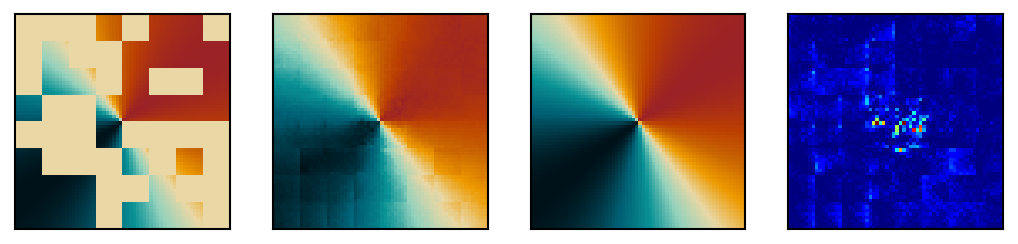

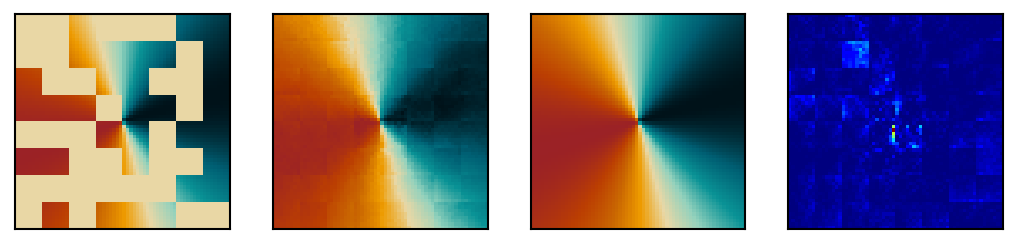

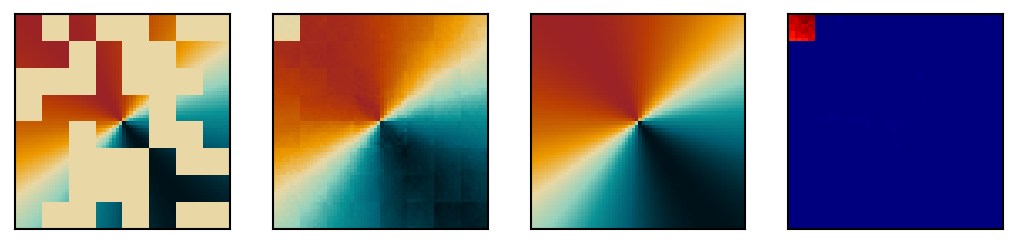

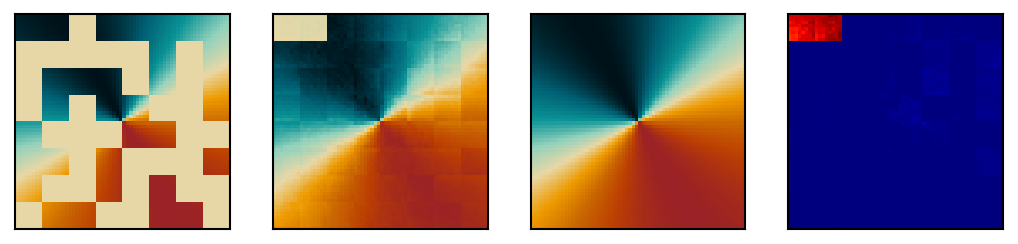

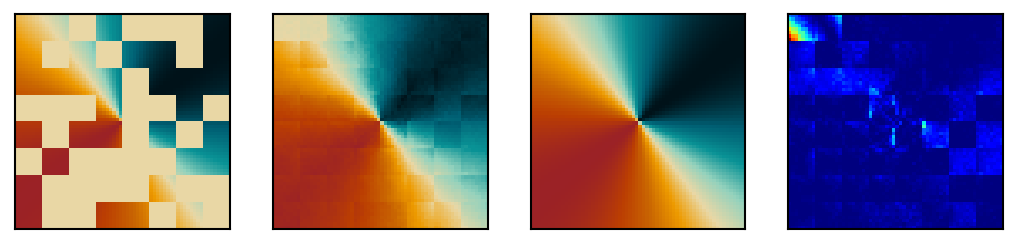

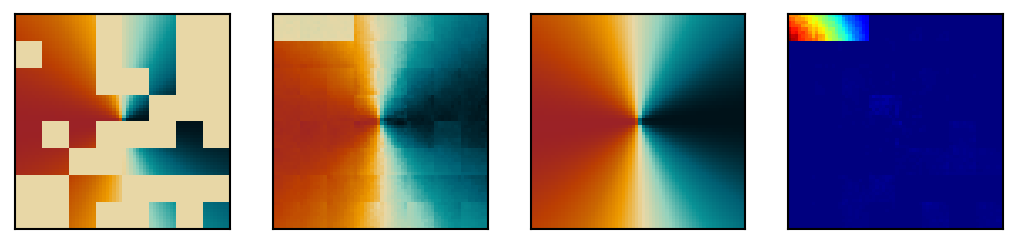

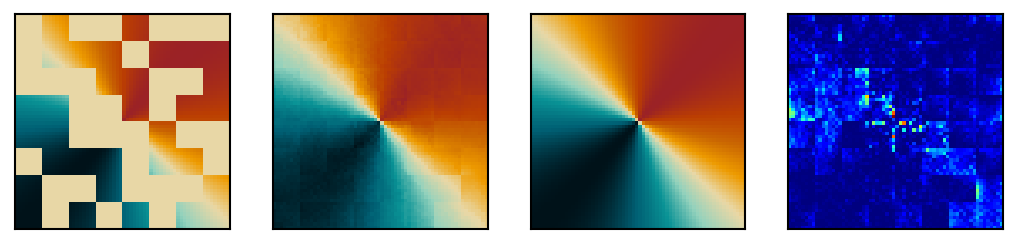

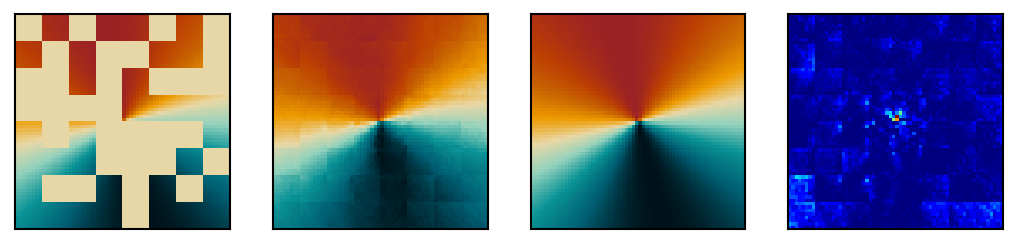

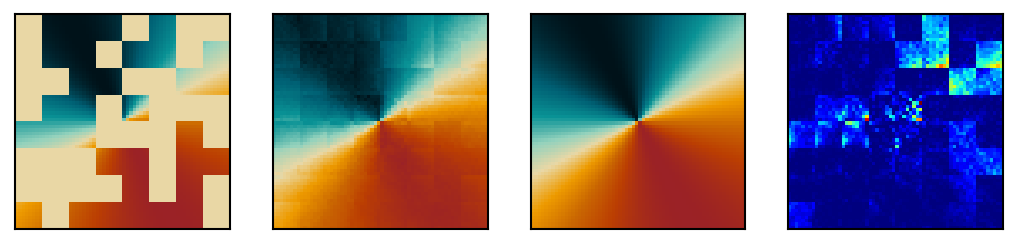

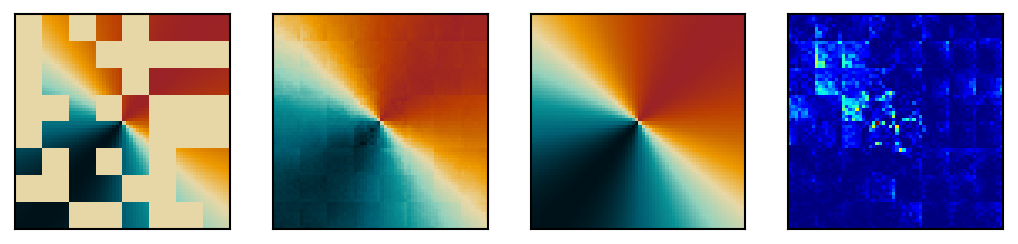

In [45]:
for i in range(10):
    plt.subplot(141); plt.imshow(x_masked[i]); plt.xticks([]); plt.yticks([])
    plt.subplot(142); plt.imshow(x_pred[i]); plt.xticks([]); plt.yticks([])
    plt.subplot(143); plt.imshow(x[i]); plt.xticks([]); plt.yticks([])
    plt.subplot(144); plt.imshow(loss_ce[i], cmap='jet'); plt.xticks([]); plt.yticks([])
    plt.show()

In [44]:
jnp.sort(metrics['idx_keep'][3])

Array([ 2,  8,  9, 10, 11, 12, 14, 16, 20, 22, 24, 26, 29, 30, 33, 34, 35,
       38, 39, 42, 44, 45, 46, 49, 50, 52, 54, 55, 56, 59, 60, 63],      dtype=int32)